In [330]:
import numpy as np

In [331]:
import pandas as pd

In [332]:
df=pd.read_csv("yellow_tripdata_2020-01 (1).csv")

C:\Users\user\AppData\Local\Temp\ipykernel_22504\315992965.py:1: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("yellow_tripdata_2020-01 (1).csv")


In [333]:
df.shape

(6405008, 18)

In [334]:
df.isnull().sum()

VendorID                 65441
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          65441
trip_distance                0
RatecodeID               65441
store_and_fwd_flag       65441
PULocationID                 0
DOLocationID                 0
payment_type             65441
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64

In [335]:
#dropping unnecessary columns
df=df.drop(columns=['VendorID','RatecodeID','store_and_fwd_flag'])


In [336]:
df.isnull().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          65441
trip_distance                0
PULocationID                 0
DOLocationID                 0
payment_type             65441
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64

In [337]:
df['passenger_count'].mode()[0]

np.float64(1.0)

In [338]:
df['payment_type'].mode()[0]

np.float64(1.0)

In [339]:
#replacing null values with the mode value
df['passenger_count']=df['passenger_count'].fillna(df['passenger_count'].mode()[0])
df['passenger_count'].isnull().sum()


np.int64(0)

In [340]:
#replacing null values with the mode value
df['payment_type']=df['payment_type'].fillna(df['payment_type'].mode()[0])
df['payment_type'].isnull().sum()

np.int64(0)

In [341]:
df.isnull().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64

In [342]:
df.duplicated().sum()

np.int64(12949)

In [343]:
# Add serial number column
df.reset_index(drop=True, inplace=True)


df['serial_no'] = np.arange(1, len(df) + 1)


cols = ['serial_no'] + [col for col in df.columns if col != 'serial_no']
df = df[cols]


print(df.head())


   serial_no tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0          1  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0   
1          2  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0   
2          3  2020-01-01 00:47:41   2020-01-01 00:53:52              1.0   
3          4  2020-01-01 00:55:23   2020-01-01 01:00:14              1.0   
4          5  2020-01-01 00:01:58   2020-01-01 00:04:16              1.0   

   trip_distance  PULocationID  DOLocationID  payment_type  fare_amount  \
0            1.2           238           239           1.0          6.0   
1            1.2           239           238           1.0          7.0   
2            0.6           238           238           1.0          6.0   
3            0.8           238           151           1.0          5.5   
4            0.0           193           193           2.0          3.5   

   extra  mta_tax  tip_amount  tolls_amount  improvement_surcharge  \
0    3.0      0.5     

In [344]:

df.reset_index(drop=True, inplace=True)


df.set_index('serial_no', inplace=True)


print(df.head())
print("Index name:", df.index.name)


          tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
serial_no                                                               
1          2020-01-01 00:28:15   2020-01-01 00:33:03              1.0   
2          2020-01-01 00:35:39   2020-01-01 00:43:04              1.0   
3          2020-01-01 00:47:41   2020-01-01 00:53:52              1.0   
4          2020-01-01 00:55:23   2020-01-01 01:00:14              1.0   
5          2020-01-01 00:01:58   2020-01-01 00:04:16              1.0   

           trip_distance  PULocationID  DOLocationID  payment_type  \
serial_no                                                            
1                    1.2           238           239           1.0   
2                    1.2           239           238           1.0   
3                    0.6           238           238           1.0   
4                    0.8           238           151           1.0   
5                    0.0           193           193           2.0  

In [345]:
df.describe()

,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06
mean,1.510067e+00,2.929644e+00,1.647323e+02,1.626627e+02,1.267536e+00,1.269411e+01,1.115456e+00,4.923182e-01,2.189342e+00,3.488395e-01,2.979870e-01,1.866315e+01,2.275662e+00
std,1.146868e+00,8.315911e+01,6.554374e+01,6.991261e+01,4.723536e-01,1.212730e+01,1.260054e+00,7.374184e-02,2.760028e+00,1.766978e+00,3.385937e-02,1.475736e+01,7.352646e-01
min,0.000000e+00,-3.062000e+01,1.000000e+00,1.000000e+00,1.000000e+00,-1.238000e+03,-2.700000e+01,-5.000000e-01,-9.100000e+01,-3.574000e+01,-3.000000e-01,-1.242300e+03,-2.500000e+00
25%,1.000000e+00,9.600000e-01,1.320000e+02,1.130000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,2.500000e+00
50%,1.000000e+00,1.600000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,5.000000e-01,5.000000e-01,1.950000e+00,0.000000e+00,3.000000e-01,1.430000e+01,2.500000e+00
75%,2.000000e+00,2.930000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.400000e+01,2.500000e+00,5.000000e-01,2.860000e+00,0.000000e+00,3.000000e-01,1.980000e+01,2.500000e+00
max,9.000000e+00,2.102401e+05,2.650000e+02,2.650000e+02,5.000000e+00,4.265000e+03,1.130100e+02,3.080000e+01,1.100000e+03,9.105000e+02,3.000000e-01,4.268300e+03,2.750000e+00


In [346]:
# Keep only positive fares whose value is greater then 0
df = df[df['fare_amount'] > 0]

# IQR calculation
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR


df = df[(df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound)]


print("fare_amount range after cleaning:", df['fare_amount'].min(), "to", df['fare_amount'].max())


fare_amount range after cleaning: 0.01 to 25.25


In [347]:
df = df[df['tip_amount'] >= 0]

Q1 = df['tip_amount'].quantile(0.25)
Q3 = df['tip_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df = df[(df['tip_amount'] >= lower_bound) & (df['tip_amount'] <= upper_bound)]

print("tip_amount range after cleaning:", df['tip_amount'].min(), "to", df['tip_amount'].max())


tip_amount range after cleaning: 0.0 to 6.65


In [348]:
df = df[df['tolls_amount'] >= 0]

print("tolls_amount range after cleaning:", df['tolls_amount'].min(), "to", df['tolls_amount'].max())


tolls_amount range after cleaning: 0.0 to 165.35


In [349]:
df = df[df['total_amount'] > 0]

Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df = df[(df['total_amount'] >= lower_bound) & (df['total_amount'] <= upper_bound)]

print("total_amount range after cleaning:", df['total_amount'].min(), "to", df['total_amount'].max())


total_amount range after cleaning: 0.36 to 28.2


In [350]:
df = df[df['trip_distance'] > 0]

Q1 = df['trip_distance'].quantile(0.25)
Q3 = df['trip_distance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df = df[(df['trip_distance'] >= lower_bound) & (df['trip_distance'] <= upper_bound)]

print("trip_distance range after cleaning:", df['trip_distance'].min(), "to", df['trip_distance'].max())


trip_distance range after cleaning: 0.01 to 4.39


In [351]:
df.describe()

,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06,5.262323e+06
mean,1.514566e+00,1.602636e+00,1.676917e+02,1.662629e+02,1.260922e+00,8.707550e+00,1.126260e+00,4.992623e-01,1.656457e+00,5.129185e-03,2.999539e-01,1.388941e+01,2.386421e+00
std,1.153078e+00,9.239270e-01,6.590120e+01,6.791624e+01,4.536217e-01,3.519022e+00,1.232364e+00,2.360892e-02,1.288772e+00,1.808755e-01,3.717105e-03,4.246186e+00,5.206152e-01
min,0.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,-2.700000e+01,-5.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,4.100000e-01,0.000000e+00
25%,1.000000e+00,9.000000e-01,1.270000e+02,1.140000e+02,1.000000e+00,6.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.080000e+01,2.500000e+00
50%,1.000000e+00,1.400000e+00,1.630000e+02,1.630000e+02,1.000000e+00,8.000000e+00,5.000000e-01,5.000000e-01,1.850000e+00,0.000000e+00,3.000000e-01,1.330000e+01,2.500000e+00
75%,2.000000e+00,2.110000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.100000e+01,2.500000e+00,5.000000e-01,2.550000e+00,0.000000e+00,3.000000e-01,1.656000e+01,2.500000e+00
max,8.000000e+00,4.390000e+00,2.650000e+02,2.650000e+02,4.000000e+00,2.522000e+01,1.350000e+01,3.080000e+01,6.650000e+00,2.500000e+01,3.000000e-01,2.820000e+01,2.750000e+00


In [352]:
# Convert timestamp strings to datetime objects
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Calculate trip duration in minutes
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Extract time-based features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)


In [353]:
# Calculate average trip speed in mph 
df['avg_speed_mph'] = df['trip_distance'] / (df['trip_duration_min'] / 60.0)
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration_min,pickup_hour,pickup_day,pickup_month,is_weekend,avg_speed_mph
serial_no,,,,,,,,,,,,,,,,,,,,,
1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,238,239,1.0,6.00,3.00,0.5,...,0.0,0.3,11.27,2.5,4.800000,0,Wednesday,1,0,15.000000
2,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,239,238,1.0,7.00,3.00,0.5,...,0.0,0.3,12.30,2.5,7.416667,0,Wednesday,1,0,9.707865
3,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,238,238,1.0,6.00,3.00,0.5,...,0.0,0.3,10.80,2.5,6.183333,0,Wednesday,1,0,5.822102
4,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,238,151,1.0,5.50,0.50,0.5,...,0.0,0.3,8.16,0.0,4.850000,0,Wednesday,1,0,9.896907
6,2020-01-01 00:09:44,2020-01-01 00:10:37,1.0,0.03,7,193,2.0,2.50,0.50,0.5,...,0.0,0.3,3.80,0.0,0.883333,0,Wednesday,1,0,2.037736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6404989,2020-01-31 22:18:00,2020-01-31 22:41:00,1.0,4.32,77,85,1.0,17.83,8.25,0.5,...,0.0,0.3,26.88,0.0,23.000000,22,Friday,1,0,11.269565
6404998,2020-01-31 22:21:13,2020-01-31 22:53:56,1.0,3.19,100,148,1.0,18.06,2.75,0.0,...,0.0,0.3,21.11,0.0,32.716667,22,Friday,1,0,5.850229
6405001,2020-01-31 22:34:00,2020-01-31 22:48:00,1.0,2.70,61,36,1.0,19.56,2.75,0.5,...,0.0,0.3,23.11,0.0,14.000000,22,Friday,1,0,11.571429


In [354]:
# Categorize times of day
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['pickup_hour'].apply(get_time_of_day)
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,...,improvement_surcharge,total_amount,congestion_surcharge,trip_duration_min,pickup_hour,pickup_day,pickup_month,is_weekend,avg_speed_mph,time_of_day
serial_no,,,,,,,,,,,,,,,,,,,,,
1,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.20,238,239,1.0,6.00,3.00,0.5,...,0.3,11.27,2.5,4.800000,0,Wednesday,1,0,15.000000,Night
2,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.20,239,238,1.0,7.00,3.00,0.5,...,0.3,12.30,2.5,7.416667,0,Wednesday,1,0,9.707865,Night
3,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.60,238,238,1.0,6.00,3.00,0.5,...,0.3,10.80,2.5,6.183333,0,Wednesday,1,0,5.822102,Night
4,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.80,238,151,1.0,5.50,0.50,0.5,...,0.3,8.16,0.0,4.850000,0,Wednesday,1,0,9.896907,Night
6,2020-01-01 00:09:44,2020-01-01 00:10:37,1.0,0.03,7,193,2.0,2.50,0.50,0.5,...,0.3,3.80,0.0,0.883333,0,Wednesday,1,0,2.037736,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6404989,2020-01-31 22:18:00,2020-01-31 22:41:00,1.0,4.32,77,85,1.0,17.83,8.25,0.5,...,0.3,26.88,0.0,23.000000,22,Friday,1,0,11.269565,Night
6404998,2020-01-31 22:21:13,2020-01-31 22:53:56,1.0,3.19,100,148,1.0,18.06,2.75,0.0,...,0.3,21.11,0.0,32.716667,22,Friday,1,0,5.850229,Night
6405001,2020-01-31 22:34:00,2020-01-31 22:48:00,1.0,2.70,61,36,1.0,19.56,2.75,0.5,...,0.3,23.11,0.0,14.000000,22,Friday,1,0,11.571429,Night


<Figure size 1200x600 with 0 Axes>

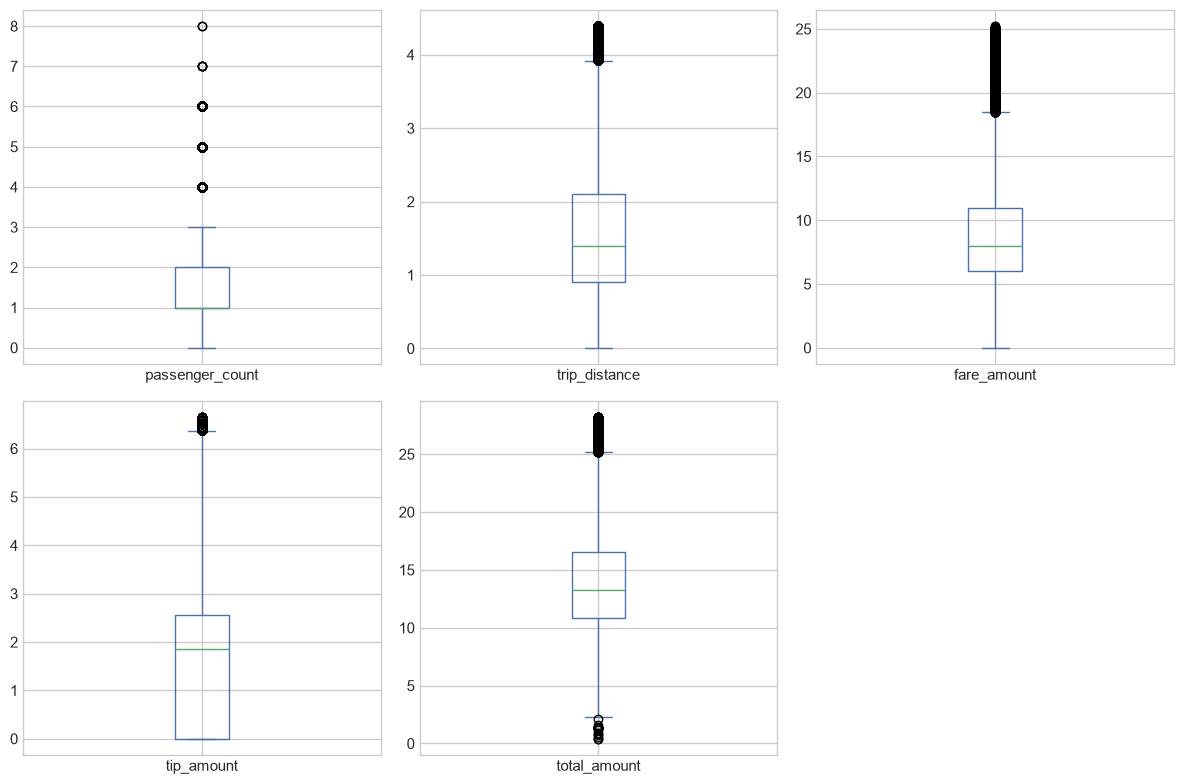

In [355]:
#analysing outliers
import matplotlib.pyplot as plt

numeric_cols = ['passenger_count','trip_distance','fare_amount','tip_amount','total_amount']

plt.figure(figsize=(12,6))
df[numeric_cols].plot(kind='box', subplots=True, layout=(2,3), figsize=(12,8), sharey=False)
plt.tight_layout()


plt.show()


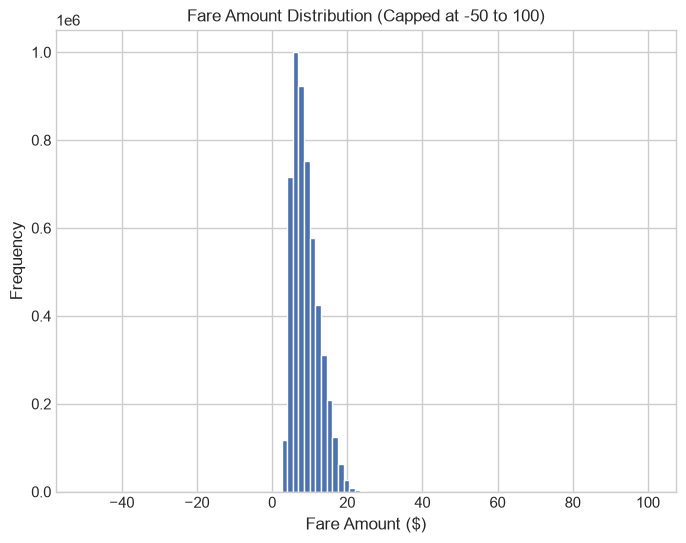

In [356]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df['fare_amount'].hist(bins=100, range=(-50,100))  
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.title('Fare Amount Distribution (Capped at -50 to 100)')
plt.show()



In [357]:
df['is_weekend'].value_counts()

is_weekend
0    4004042
1    1258281
Name: count, dtype: int64

In [358]:
df['pickup_day'].value_counts()

pickup_day
Friday       928036
Thursday     911602
Wednesday    861419
Tuesday      703764
Saturday     682828
Monday       599221
Sunday       575453
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Trip Demand by Pickup Hour
sns.countplot(x='pickup_hour', data=df, ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Trip Demand by Pickup Hour")
axes[0,0].set_xlabel("Hour of Day (0–23)")
axes[0,0].set_ylabel("Total Trips")

# 2. Distribution of Trip Distance
sns.histplot(df['trip_distance'], bins=50, kde=True, ax=axes[0,1], color="green")
axes[0,1].set_title("Distribution of Trip Distance (Miles)")
axes[0,1].set_xlabel("Trip Distance")
axes[0,1].set_ylabel("Count")

# 3. Average Speed by Time of Day
sns.barplot(x='time_of_day', y='avg_speed_mph', data=df, ax=axes[1,0], 
            order=['Morning','Afternoon','Evening','Night'], palette="mako")
axes[1,0].set_title("Average Speed (mph) by Time of Day")
axes[1,0].set_xlabel("Time of Day")
axes[1,0].set_ylabel("Average Speed (mph)")

# 4. Feature Correlation Matrix
corr = df[['trip_distance','trip_duration_min','fare_amount',
           'tip_amount','total_amount','avg_speed_mph']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1,1])
axes[1,1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_22504\2568783527.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pickup_hour', data=df, ax=axes[0,0], palette="viridis")
C:\Users\user\AppData\Local\Temp\ipykernel_22504\2568783527.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='time_of_day', y='avg_speed_mph', data=df, ax=axes[1,0],


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Prepare data
# -------------------------------
# Trips by day of week
trips_by_day = clean_df['pickup_day'].value_counts()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
trips_by_day = trips_by_day.reindex(day_order)
max_day = trips_by_day.idxmax()
max_trips = trips_by_day.max()

# Payment type mapping (only 1–4 used here)
payment_labels = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute'
}
df_filtered = clean_df[clean_df['payment_type'].isin([1,2,3,4])].copy()
df_filtered['payment_name'] = df_filtered['payment_type'].map(payment_labels)

# -------------------------------
# Create 2x2 subplot layout
# -------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11,8))
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Payment Preferences by Time of Day
sns.countplot(x='time_of_day', hue='payment_name', data=df_filtered, palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Payment Preferences by Time of Day")
axes[0,0].set_xlabel("Time of Day")
axes[0,0].set_ylabel("Number of Trips")

# Move legend outside the plot
axes[0,0].legend(title="Payment Method", bbox_to_anchor=(1.05, 1), loc='upper left')


# 2. Donut Chart: Trips by Day of Week
colors = ['#52b788','#2a9d8f','#e76f51','#f4a261','#e63946','#457b9d','#1d3557']
explode = [0.08 if day == max_day else 0 for day in day_order]
wedges, texts, autotexts = axes[0,1].pie(
    trips_by_day, labels=trips_by_day.index, autopct='%1.1f%%',
    startangle=140, colors=colors, explode=explode,
    pctdistance=0.78, textprops={'fontsize':10,'weight':'bold'}
)
centre_circle = plt.Circle((0,0),0.60,fc='white')
axes[0,1].add_artist(centre_circle)
axes[0,1].set_title("Total Taxi Trips by Day of Week")
axes[0,1].text(0,0,f"Peak Day:\n{max_day}\n({max_trips:,} Trips)",
               ha='center', va='center', fontsize=11, fontweight='bold', color='#FFFFFF')
plt.setp(autotexts, color='white')

# 3. Average Fare by Payment Type (Bar Plot)
ax = sns.barplot(data=df_filtered, x='payment_name', y='total_amount',
                 palette=['#2a9d8f','#e76f51','#f4a261','#457b9d'], errorbar=None,
                 edgecolor='black', width=0.4, ax=axes[1,0])
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'${height:.2f}', (p.get_x()+p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                xytext=(0,5), textcoords='offset points')
ax.set_title("Average Total Fare Amount by Payment Type")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Average Total Fare ($)")
ax.set_ylim(0, df_filtered.groupby('payment_name')['total_amount'].mean().max()*1.15)

# 4. Trip Distance Distribution (Histogram)
sns.histplot(clean_df['trip_distance'], bins=50, kde=False, color='#457b9d', ax=axes[1,1])
axes[1,1].set_title("Distribution of Trip Distance (Miles)")
axes[1,1].set_xlabel("Trip Distance")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:

from scipy import stats


card_fares = clean_df[clean_df['payment_type'] == 1]['total_amount']
cash_fares = clean_df[clean_df['payment_type'] == 2]['total_amount']

#F-Test
f_stat, p_value = stats.f_oneway(card_fares, cash_fares)


print(f"F-Statistic : {f_stat:.2f}")
print(f"P-Value     : {p_value}")


if p_value < 0.05:
    print("\nDecision: REJECT null hypothesis.")
    print("Conclusion: There IS a significant relationship between total fare amount and payment type.")
else:
    print("\nDecision: FAIL TO REJECT null hypothesis.")
    print("Conclusion: No significant relationship found.")